# Preprocessing — fit on training split, save artifacts, produce PDF briefing

**Notebook role:** Phase 2. Fits the canonical preprocessing pipeline on the train windows, picks the range-bin window from the energy curve, saves all artifacts, and produces a PDF briefing for the report.

**Outputs**
- `other_files/normalization_stats.npz` — used by training and `code.py`
- `other_files/figs_eda/preproc_*.png` — figures
- `other_files/eda_preproc.pdf` — briefing PDF

**Pipeline** (matches `preprocessing.py`):
1. Causal EMA clutter removal (alpha = 0.02, tau ~ 50 frames)
2. Range-bin crop (lo, hi) such that 99% of post-clutter energy is preserved
3. Per (radar, antenna, channel) z-score using stats from train split only


## 0. Setup

In [1]:
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=3, suppress=True)

# Make preprocessing.py importable
ROOT = Path("..").resolve()
OTHER_FILES = ROOT / "other_files"
sys.path.insert(0, str(OTHER_FILES))

from preprocessing import (
    Preprocessor, EMAClutterRemover, RunningMeanClutterRemover,
    energy_per_bin, pick_bin_range,
)

DATA_DIR    = ROOT / "data" / "multi-person-localization"
WINDOWS_DIR = DATA_DIR / "data"
FIG_DIR     = OTHER_FILES / "figs_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

window_files = sorted(WINDOWS_DIR.glob("window_*.npz"))
print(f"Found {len(window_files)} windows")


Found 24 windows


## 1. Split definition (frozen)

Same window-level split as Section 4.4 of the report. Frozen — do **not** change without re-running everything downstream.


In [2]:
TRAIN_IDS = [0, 1, 3, 5, 6, 7, 9, 11, 12, 13, 16, 17, 18, 19, 22, 23]
VAL_IDS   = [4, 8, 14, 20]
TEST_IDS  = [2, 10, 15, 21]

assert sorted(TRAIN_IDS + VAL_IDS + TEST_IDS) == list(range(24))
train_paths = [window_files[i] for i in TRAIN_IDS]
val_paths   = [window_files[i] for i in VAL_IDS]
test_paths  = [window_files[i] for i in TEST_IDS]

print(f"Train: {len(train_paths)} windows -> {len(train_paths)*7500:,} frames")
print(f"Val:   {len(val_paths)} windows -> {len(val_paths)*7500:,} frames")
print(f"Test:  {len(test_paths)} windows -> {len(test_paths)*7500:,} frames")


Train: 16 windows -> 120,000 frames
Val:   4 windows -> 30,000 frames
Test:  4 windows -> 30,000 frames


## 2. Sanity check — running-mean vs causal EMA

The EDA used a centred running mean (W=50). Deployment requires a causal filter, so training will use a causal EMA (alpha=0.02, tau ~ 50 frames). Compare them on one window to confirm the EMA gives a comparable signal.


In [3]:
# Pick a busy 4-people window
sample_path = window_files[5]   # w05 = random walk, 4 subjects
with np.load(sample_path) as f:
    cir = f["radar_cir_iq"].astype(np.float32)
    ts  = f["timestamps"]
print(f"Loaded {sample_path.name}: shape {cir.shape}")

rm = RunningMeanClutterRemover(window=50)
em = EMAClutterRemover(alpha=0.02, warmup=50)

cir_rm = rm(cir)
cir_em = em(cir)

# Magnitude after each method
mag_raw = np.sqrt(cir[..., 0]**2 + cir[..., 1]**2)
mag_rm  = np.sqrt(cir_rm[..., 0]**2 + cir_rm[..., 1]**2)
mag_em  = np.sqrt(cir_em[..., 0]**2 + cir_em[..., 1]**2)

print(f"  raw |CIR|:   mean={mag_raw.mean():.3g}  max={mag_raw.max():.3g}")
print(f"  RM cleaned:  mean={mag_rm.mean():.3g}   max={mag_rm.max():.3g}")
print(f"  EMA cleaned: mean={mag_em.mean():.3g}   max={mag_em.max():.3g}")


Loaded window_000005.npz: shape (7500, 6, 3, 120, 2)
  raw |CIR|:   mean=1.34e+03  max=3.56e+04
  RM cleaned:  mean=34.2   max=1.61e+04
  EMA cleaned: mean=34.4   max=1.6e+04


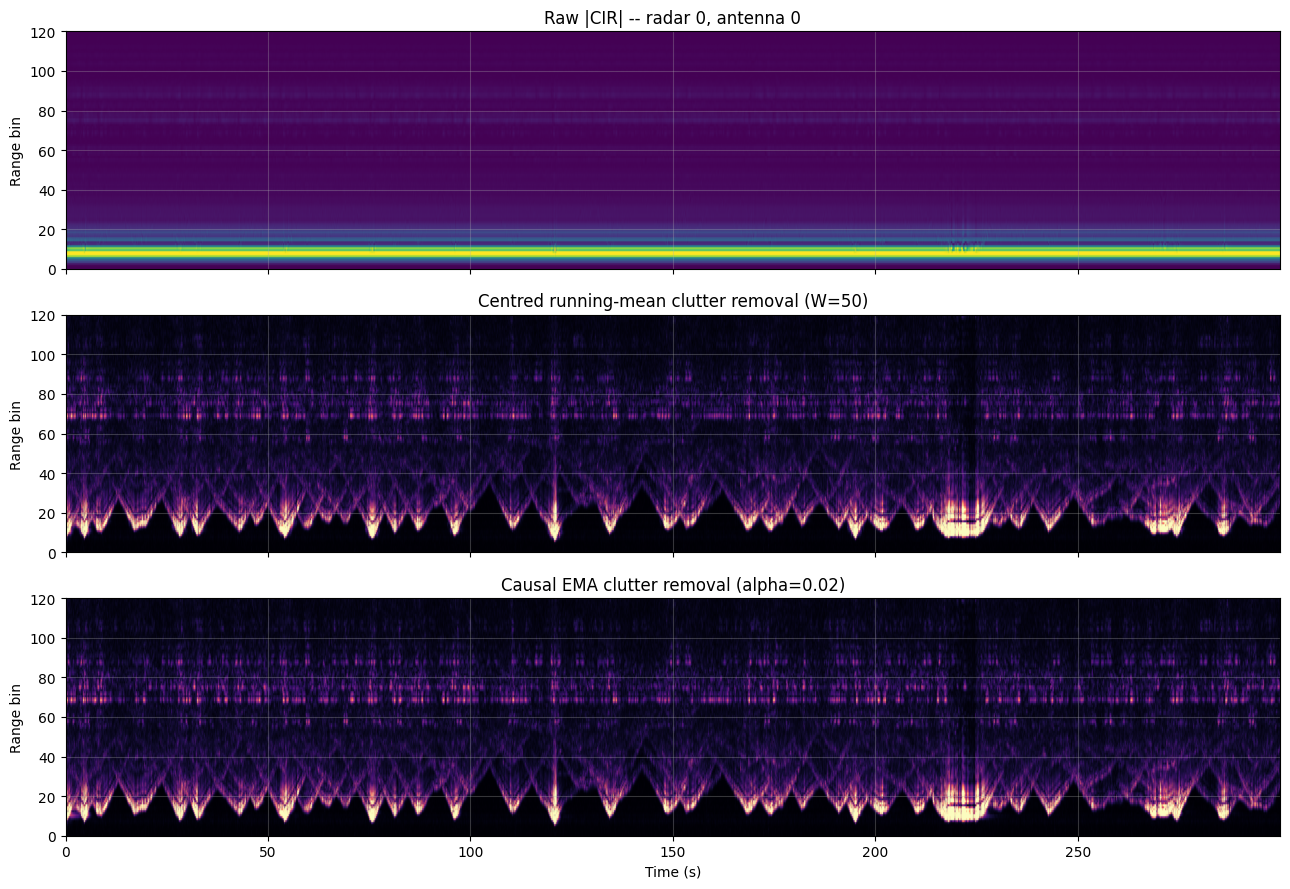

In [4]:
# Side-by-side range-time maps for one radar/antenna
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
RADAR, ANT = 0, 0
extent = [ts[0], ts[-1], 0, 120]

vmax_raw   = np.percentile(mag_raw[:, RADAR, ANT], 99)
vmax_clean = np.percentile(np.r_[mag_rm[:, RADAR, ANT].ravel(),
                                  mag_em[:, RADAR, ANT].ravel()], 99)

axes[0].imshow(mag_raw[:, RADAR, ANT].T, aspect="auto", origin="lower",
               extent=extent, cmap="viridis", vmin=0, vmax=vmax_raw)
axes[0].set_title(f"Raw |CIR| -- radar {RADAR}, antenna {ANT}")
axes[0].set_ylabel("Range bin")

axes[1].imshow(mag_rm[:, RADAR, ANT].T, aspect="auto", origin="lower",
               extent=extent, cmap="magma", vmin=0, vmax=vmax_clean)
axes[1].set_title("Centred running-mean clutter removal (W=50)")
axes[1].set_ylabel("Range bin")

axes[2].imshow(mag_em[:, RADAR, ANT].T, aspect="auto", origin="lower",
               extent=extent, cmap="magma", vmin=0, vmax=vmax_clean)
axes[2].set_title("Causal EMA clutter removal (alpha=0.02)")
axes[2].set_ylabel("Range bin")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig(FIG_DIR / "preproc_clutter_comparison.png", bbox_inches="tight")
plt.show()


## 3. Range-bin energy curve (training data, post-EMA)

Compute the average per-bin energy after EMA clutter removal across all training windows. This determines the bin-crop window: we keep the contiguous range that holds 99% of the post-clutter energy.


In [ ]:
print("Computing per-bin energy across training windows...")
e_per_bin = np.zeros(120, dtype=np.float64)

for i, p in enumerate(train_paths):
    with np.load(p) as f:
        cir = f["radar_cir_iq"].astype(np.float32)
    em = EMAClutterRemover(alpha=0.02, warmup=50)
    cir_clean = em(cir)
    e_per_bin += energy_per_bin(cir_clean)
    print(f"  [{i+1:2d}/{len(train_paths)}] {p.name}")

e_per_bin /= len(train_paths)

Computing per-bin energy across training windows...
  [ 1/16] window_000000.npz
  [ 2/16] window_000001.npz
  [ 3/16] window_000003.npz
  [ 4/16] window_000005.npz
  [ 5/16] window_000006.npz
  [ 6/16] window_000007.npz
  [ 7/16] window_000009.npz
  [ 8/16] window_000011.npz
  [ 9/16] window_000012.npz
  [10/16] window_000013.npz
  [11/16] window_000016.npz
  [12/16] window_000017.npz
  [13/16] window_000018.npz
  [14/16] window_000019.npz
  [15/16] window_000022.npz
  [16/16] window_000023.npz
Done.


In [6]:
bin_lo, bin_hi = pick_bin_range(e_per_bin, keep_fraction=0.99)
total_e = e_per_bin.sum()
kept_e  = e_per_bin[bin_lo:bin_hi].sum()
print(f"Energy curve: total={total_e:.3g}")
print(f"Chosen window: [{bin_lo}, {bin_hi})  ({bin_hi-bin_lo} bins)")
print(f"Energy retained: {100*kept_e/total_e:.2f} %")
print(f"Energy dropped : {100*(total_e-kept_e)/total_e:.2f} %  "
      f"({100*e_per_bin[:bin_lo].sum()/total_e:.2f}% near-field, "
      f"{100*e_per_bin[bin_hi:].sum()/total_e:.2f}% far-field)")


Energy curve: total=5.74e+05
Chosen window: [6, 111)  (105 bins)
Energy retained: 99.34 %
Energy dropped : 0.66 %  (0.15% near-field, 0.51% far-field)


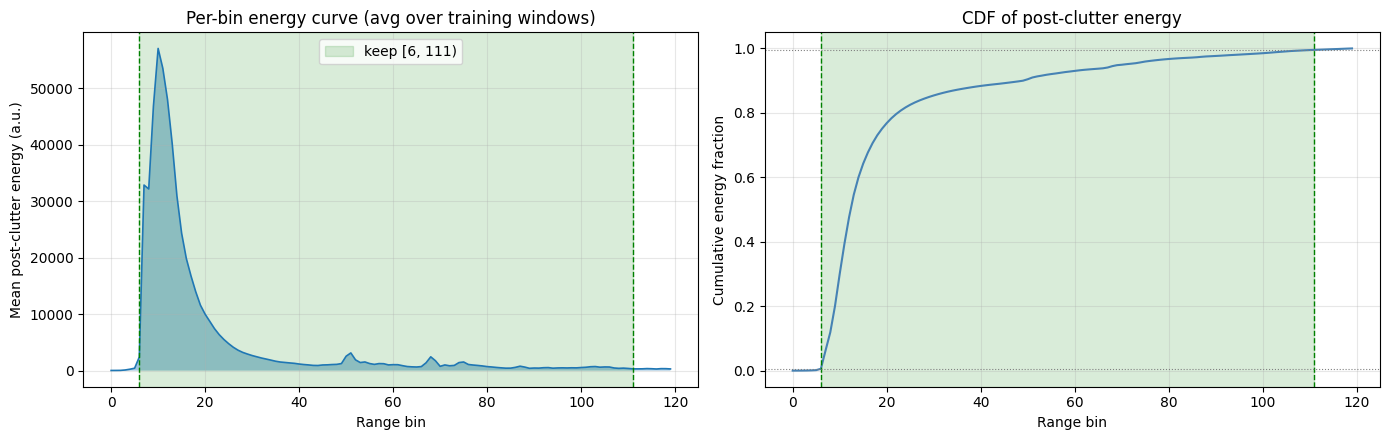

In [7]:
# Plot the curve and the chosen window
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

bins = np.arange(120)
axes[0].fill_between(bins, e_per_bin, alpha=0.4)
axes[0].plot(bins, e_per_bin, linewidth=1.2)
axes[0].axvspan(bin_lo, bin_hi, color="green", alpha=0.15, label=f"keep [{bin_lo}, {bin_hi})")
axes[0].axvline(bin_lo, color="green", linestyle="--", linewidth=1)
axes[0].axvline(bin_hi, color="green", linestyle="--", linewidth=1)
axes[0].set_xlabel("Range bin")
axes[0].set_ylabel("Mean post-clutter energy (a.u.)")
axes[0].set_title("Per-bin energy curve (avg over training windows)")
axes[0].legend()

# CDF view
cdf = np.cumsum(e_per_bin) / e_per_bin.sum()
axes[1].plot(bins, cdf, linewidth=1.5, color="steelblue")
axes[1].axvspan(bin_lo, bin_hi, color="green", alpha=0.15)
axes[1].axvline(bin_lo, color="green", linestyle="--", linewidth=1)
axes[1].axvline(bin_hi, color="green", linestyle="--", linewidth=1)
axes[1].axhline(0.005, color="grey", linestyle=":", linewidth=0.8)
axes[1].axhline(0.995, color="grey", linestyle=":", linewidth=0.8)
axes[1].set_xlabel("Range bin")
axes[1].set_ylabel("Cumulative energy fraction")
axes[1].set_title("CDF of post-clutter energy")

plt.tight_layout()
plt.savefig(FIG_DIR / "preproc_energy_curve.png", bbox_inches="tight")
plt.show()


## 4. Fit preprocessor (train split only) and save

This produces `normalization_stats.npz`, the artifact loaded by `code.py` at inference time.


In [8]:
pp = Preprocessor.fit(
    train_window_paths=train_paths,
    clutter="ema",
    ema_alpha=0.02,
    warmup=50,
    energy_keep=0.99,
    max_frames_for_stats=30000,   # ~10 windows of frames is plenty for stable stats
    verbose=True,
)

print()
print(f"Result: bin_lo={pp.bin_lo}, bin_hi={pp.bin_hi}")
print(f"        norm.mean shape: {pp.norm.mean.shape}, dtype: {pp.norm.mean.dtype}")
print(f"        norm.std  shape: {pp.norm.std.shape}")

stats_path = OTHER_FILES / "normalization_stats.npz"
pp.save(stats_path)
print(f"\nSaved: {stats_path}  ({stats_path.stat().st_size/1024:.1f} KB)")


[fit] Pass 1/2: per-bin energy on 16 windows...
  [1/16] window_000000.npz -> energy sum 4.27e+05
  [2/16] window_000001.npz -> energy sum 5.63e+05
  [3/16] window_000003.npz -> energy sum 3.41e+05
  [4/16] window_000005.npz -> energy sum 1.25e+06
  [5/16] window_000006.npz -> energy sum 1.15e+06
  [6/16] window_000007.npz -> energy sum 1.26e+06
  [7/16] window_000009.npz -> energy sum 1.24e+06
  [8/16] window_000011.npz -> energy sum 4.9e+05
  [9/16] window_000012.npz -> energy sum 8.35e+05
  [10/16] window_000013.npz -> energy sum 7.44e+05
  [11/16] window_000016.npz -> energy sum 1.98e+05
  [12/16] window_000017.npz -> energy sum 2.02e+05
  [13/16] window_000018.npz -> energy sum 2.05e+05
  [14/16] window_000019.npz -> energy sum 2.8e+05
  [15/16] window_000022.npz -> energy sum 4.36e+03
  [16/16] window_000023.npz -> energy sum 5.13e+03
[fit] Energy curve has 120 bins; keeping [6, 111) (105 bins, 99.0% energy)
[fit] Pass 2/2: mean/std (Welford) on cropped data...
  [1/16] frames_se

In [9]:
# Per (radar, antenna) summary of mean/std
print("Per-radar mean/std summary (channel 0=I, channel 1=Q):\n")
print(f"{'R':>2} {'A':>2}   meanI    stdI    meanQ    stdQ")
print("-"*40)
for r in range(pp.norm.mean.shape[0]):
    for a in range(pp.norm.mean.shape[1]):
        m = pp.norm.mean[r, a]
        s = pp.norm.std[r, a]
        print(f"{r:>2} {a:>2}  {m[0]:>7.2f} {s[0]:>7.2f}  {m[1]:>7.2f} {s[1]:>7.2f}")


Per-radar mean/std summary (channel 0=I, channel 1=Q):

 R  A   meanI    stdI    meanQ    stdQ
----------------------------------------
 0  0     0.00   93.44     0.00   94.29
 0  1     0.00   36.73     0.00   36.89
 0  2    -0.00   13.31    -0.00   13.46
 1  0     0.00   82.45     0.00   80.52
 1  1     0.00   26.44     0.00   26.59
 1  2    -0.00   11.62    -0.00   11.91
 2  0     0.00   97.93    -0.00  101.20
 2  1     0.00   28.44     0.00   30.63
 2  2    -0.00   12.60    -0.00   12.39
 3  0    -0.00  109.34    -0.00  109.54
 3  1     0.00   29.09     0.00   29.42
 3  2    -0.00   12.40    -0.00   12.66
 4  0     0.00   74.48    -0.00   74.46
 4  1    -0.00   26.17    -0.00   26.45
 4  2    -0.00   12.21    -0.00   12.32
 5  0     0.00   75.57     0.01   75.19
 5  1     0.01   30.30     0.00   30.73
 5  2    -0.00   11.39    -0.00   11.59


## 5. Verify pipeline on val + test windows

Sanity check: after applying the pipeline to held-out windows, the per-channel mean should be close to 0 and the std close to 1. Significant deviation means the train split is not representative of val/test (a domain-shift warning).


In [10]:
def transform_summary(paths, label):
    means, stds = [], []
    for p in paths:
        with np.load(p) as f:
            cir = f["radar_cir_iq"].astype(np.float32)
        x = pp.transform(cir)
        means.append(x.mean(axis=(0, 3)))   # mean over time and bins -> (R, A, 2)
        stds.append(x.std(axis=(0, 3)))
    means = np.stack(means).mean(axis=0)
    stds  = np.stack(stds).mean(axis=0)
    print(f"{label}: mean ~ {means.mean():.3f} (target 0), "
          f"std ~ {stds.mean():.3f} (target 1)")
    print(f"  channel-wise mean: I={means[..., 0].mean():.3f}, Q={means[..., 1].mean():.3f}")
    print(f"  channel-wise std:  I={stds[..., 0].mean():.3f}, Q={stds[..., 1].mean():.3f}")
    return means, stds

mean_train, std_train = transform_summary(train_paths[:4], "train (4 windows)")
mean_val,   std_val   = transform_summary(val_paths,        "val  (4 windows)")
mean_test,  std_test  = transform_summary(test_paths,       "test (4 windows)")


train (4 windows): mean ~ 0.000 (target 0), std ~ 0.935 (target 1)
  channel-wise mean: I=0.000, Q=0.000
  channel-wise std:  I=0.934, Q=0.935
val  (4 windows): mean ~ -0.000 (target 0), std ~ 0.778 (target 1)
  channel-wise mean: I=-0.000, Q=-0.000
  channel-wise std:  I=0.780, Q=0.777
test (4 windows): mean ~ -0.000 (target 0), std ~ 0.684 (target 1)
  channel-wise mean: I=0.000, Q=-0.000
  channel-wise std:  I=0.684, Q=0.684


After transform on w05: shape (7500, 6, 3, 105, 2), mean 0.000, std 1.439


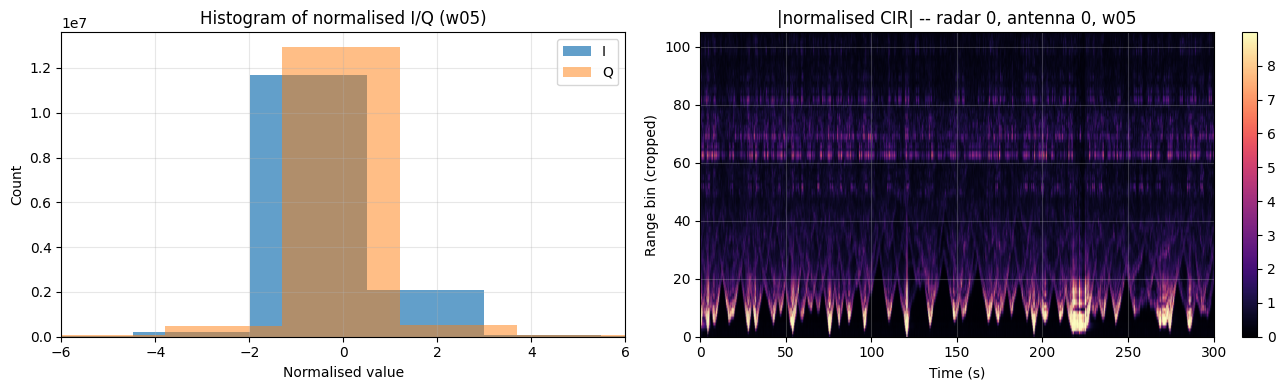

In [11]:
# Distribution of normalised values on the busy w05 window (training)
with np.load(window_files[5]) as f:
    cir = f["radar_cir_iq"].astype(np.float32)
x = pp.transform(cir)
print(f"After transform on w05: shape {x.shape}, mean {x.mean():.3f}, std {x.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(x[..., 0].ravel(), bins=120, alpha=0.7, color="tab:blue", label="I")
axes[0].hist(x[..., 1].ravel(), bins=120, alpha=0.5, color="tab:orange", label="Q")
axes[0].set_xlim(-6, 6)
axes[0].set_xlabel("Normalised value")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of normalised I/Q (w05)")
axes[0].legend()

# Range-time map after full pipeline (magnitude of the normalised I/Q)
RADAR, ANT = 0, 0
mag_norm = np.sqrt(x[:, RADAR, ANT, :, 0]**2 + x[:, RADAR, ANT, :, 1]**2)
im = axes[1].imshow(mag_norm.T, aspect="auto", origin="lower",
                    extent=[0, x.shape[0]/25, 0, x.shape[3]],
                    cmap="magma", vmin=0, vmax=np.percentile(mag_norm, 99))
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Range bin (cropped)")
axes[1].set_title(f"|normalised CIR| -- radar {RADAR}, antenna {ANT}, w05")
plt.colorbar(im, ax=axes[1], fraction=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "preproc_after_pipeline.png", bbox_inches="tight")
plt.show()


## 6. PDF briefing


In [12]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image as RLImage, PageBreak,
)
from PIL import Image as PILImage

OUT_PDF = OTHER_FILES / "eda_preproc.pdf"

ss = getSampleStyleSheet()
H1   = ParagraphStyle("H1",   parent=ss["Heading1"], fontSize=14, spaceAfter=4, spaceBefore=8,
                              textColor=colors.HexColor("#0b3d91"))
H2   = ParagraphStyle("H2",   parent=ss["Heading2"], fontSize=11, spaceAfter=2, spaceBefore=6,
                              textColor=colors.HexColor("#0b3d91"))
BODY = ParagraphStyle("body", parent=ss["BodyText"], fontSize=8.5, leading=11)
SMALL= ParagraphStyle("small",parent=ss["BodyText"], fontSize=7.5, leading=9.5)

def tbl(data, col_widths=None, font_size=7.5, header=True):
    t = Table(data, colWidths=col_widths)
    style = [
        ("FONT", (0, 0), (-1, -1), "Helvetica", font_size),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("LEFTPADDING", (0, 0), (-1, -1), 3),
        ("RIGHTPADDING", (0, 0), (-1, -1), 3),
        ("TOPPADDING", (0, 0), (-1, -1), 1.5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 1.5),
    ]
    if header:
        style += [
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#e8eef7")),
            ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", font_size),
        ]
    t.setStyle(TableStyle(style))
    return t

def fig(path, width=16*cm):
    p = Path(path)
    if not p.exists():
        return Paragraph(f"<i>(missing: {p.name})</i>", SMALL)
    with PILImage.open(p) as im:
        w, h = im.size
    return RLImage(str(p), width=width, height=width * (h / w))

doc = SimpleDocTemplate(
    str(OUT_PDF), pagesize=A4,
    leftMargin=1.5*cm, rightMargin=1.5*cm,
    topMargin=1.2*cm, bottomMargin=1.2*cm,
    title="Preprocessing Briefing - Multi-Person UWB Localization",
)
story = []

# ---- Header ----
story.append(Paragraph("Preprocessing Briefing - Multi-Person UWB Localization", H1))
story.append(Paragraph(
    f"Generated {datetime.now():%Y-%m-%d %H:%M} - "
    f"Pipeline = causal EMA clutter removal -> range-bin crop -> z-score - "
    f"Train: {len(train_paths)} windows, "
    f"Val: {len(val_paths)} windows, Test: {len(test_paths)} windows",
    SMALL,
))
story.append(Spacer(1, 4))

# ---- 1. Pipeline & params ----
story.append(Paragraph("1. Pipeline parameters", H2))
params_rows = [
    ["Stage", "Method", "Parameters"],
    ["Clutter removal", "Causal EMA", f"alpha = 0.02  (tau ~ 50 frames = 2 s);  warmup = 50 frames"],
    ["Range-bin crop", "Energy-driven", f"keep [{pp.bin_lo}, {pp.bin_hi})  ->  {pp.bin_hi-pp.bin_lo} bins  (99% energy)"],
    ["Normalisation", "z-score", "per (radar, antenna, channel); fit on train split only"],
]
story.append(tbl(params_rows, col_widths=[3.5*cm, 3.5*cm, 10*cm]))
story.append(Spacer(1, 4))

# ---- 2. Clutter comparison ----
story.append(Paragraph("2. Clutter removal: running-mean (offline) vs EMA (causal)", H2))
story.append(Paragraph(
    "The training-time and inference-time pipelines must be identical, so we adopt the "
    "causal EMA. The figure below confirms it produces a comparable post-clutter image "
    "to the offline centred running mean used in the EDA.",
    BODY,
))
story.append(fig(FIG_DIR / "preproc_clutter_comparison.png", width=17*cm))

# ---- 3. Range-bin energy curve ----
story.append(PageBreak())
story.append(Paragraph("3. Range-bin energy curve (post-EMA)", H2))
story.append(Paragraph(
    f"Per-bin |I/Q|^2 energy averaged across the {len(train_paths)} training windows, "
    f"computed after causal EMA clutter removal. The chosen crop "
    f"[{pp.bin_lo}, {pp.bin_hi}) preserves "
    f"{100*e_per_bin[pp.bin_lo:pp.bin_hi].sum()/e_per_bin.sum():.2f}% of the energy "
    f"and reduces input range from 120 to {pp.bin_hi - pp.bin_lo} bins "
    f"({100*(pp.bin_hi-pp.bin_lo)/120:.1f}% of original).",
    BODY,
))
story.append(fig(FIG_DIR / "preproc_energy_curve.png", width=17*cm))

# Table: bins dropped
crop_rows = [
    ["Region", "Bins", "Energy fraction"],
    ["Near-field tail (dropped)", f"[0, {pp.bin_lo})",   f"{100*e_per_bin[:pp.bin_lo].sum()/e_per_bin.sum():.2f} %"],
    ["Kept",                      f"[{pp.bin_lo}, {pp.bin_hi})", f"{100*e_per_bin[pp.bin_lo:pp.bin_hi].sum()/e_per_bin.sum():.2f} %"],
    ["Far-field tail (dropped)",  f"[{pp.bin_hi}, 120)", f"{100*e_per_bin[pp.bin_hi:].sum()/e_per_bin.sum():.2f} %"],
]
story.append(Spacer(1, 4))
story.append(tbl(crop_rows, col_widths=[6*cm, 4*cm, 4*cm]))

# ---- 4. Normalisation stats ----
story.append(PageBreak())
story.append(Paragraph("4. Normalisation statistics (z-score)", H2))
story.append(Paragraph(
    f"Per (radar, antenna, channel) mean and std of the post-clutter, post-crop signal, "
    f"computed on the training split only. Stats stored in "
    f"<font face='Courier'>normalization_stats.npz</font>.",
    BODY,
))
norm_rows = [["R", "A", "mean I", "std I", "mean Q", "std Q"]]
for r in range(pp.norm.mean.shape[0]):
    for a in range(pp.norm.mean.shape[1]):
        m = pp.norm.mean[r, a]; s = pp.norm.std[r, a]
        norm_rows.append([str(r), str(a),
                          f"{m[0]:.2f}", f"{s[0]:.2f}",
                          f"{m[1]:.2f}", f"{s[1]:.2f}"])
story.append(tbl(norm_rows, col_widths=[1*cm, 1*cm, 2.5*cm, 2.5*cm, 2.5*cm, 2.5*cm], font_size=7))

# ---- 5. Held-out verification ----
story.append(Spacer(1, 6))
story.append(Paragraph("5. Held-out verification", H2))
story.append(Paragraph(
    "After applying the pipeline to validation and test windows, the per-channel mean "
    "should be close to 0 and std close to 1. Significant deviation indicates a domain "
    "shift between splits.",
    BODY,
))
verify_rows = [
    ["Split", "mean I", "std I", "mean Q", "std Q"],
    ["Train (sample)", f"{mean_train[..., 0].mean():.3f}", f"{std_train[..., 0].mean():.3f}",
                       f"{mean_train[..., 1].mean():.3f}", f"{std_train[..., 1].mean():.3f}"],
    ["Validation",     f"{mean_val[..., 0].mean():.3f}",   f"{std_val[..., 0].mean():.3f}",
                       f"{mean_val[..., 1].mean():.3f}",   f"{std_val[..., 1].mean():.3f}"],
    ["Test",           f"{mean_test[..., 0].mean():.3f}",  f"{std_test[..., 0].mean():.3f}",
                       f"{mean_test[..., 1].mean():.3f}",  f"{std_test[..., 1].mean():.3f}"],
]
story.append(tbl(verify_rows, col_widths=[3.5*cm, 2.5*cm, 2.5*cm, 2.5*cm, 2.5*cm]))
story.append(Spacer(1, 4))

# ---- 6. Result figure ----
story.append(Paragraph("6. End-to-end pipeline output", H2))
story.append(Paragraph(
    "Output of the full pipeline on a representative four-people window (w05). Left: "
    "histogram of normalised I/Q values - approximately zero-mean, unit-variance, "
    "with the expected heavy tail from moving targets. Right: range-time map of the "
    "magnitude of the normalised I/Q on radar 0 antenna 0 - target tracks remain clearly "
    "visible after the full pipeline.",
    BODY,
))
story.append(fig(FIG_DIR / "preproc_after_pipeline.png", width=17*cm))

# ---- 7. Output shape ----
story.append(Spacer(1, 6))
story.append(Paragraph("7. Resulting model input shape", H2))
shape_rows = [
    ["Quantity", "Value"],
    ["Per-frame input shape", f"(6, 3, {pp.bin_hi-pp.bin_lo}, 2)"],
    ["Per-frame elements", f"{6*3*(pp.bin_hi-pp.bin_lo)*2:,}"],
    ["Per-frame size (float32)", f"{6*3*(pp.bin_hi-pp.bin_lo)*2*4/1024:.2f} KB"],
    ["Reduction vs raw 120 bins", f"{100*(pp.bin_hi-pp.bin_lo)/120:.1f} % of original size"],
]
story.append(tbl(shape_rows, col_widths=[6*cm, 6*cm], header=False))

doc.build(story)
print(f"Wrote {OUT_PDF}  ({OUT_PDF.stat().st_size/1024:.1f} KB)")


Wrote /home/aman/Projects/TinyML-UWB-MultiPerson-Localization/other_files/eda_preproc.pdf  (4056.8 KB)
